In [272]:
from sklearn.datasets import load_iris
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler


In [273]:
iris=load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data["target"] = iris.target
print(data)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     target  
0         0  

In [274]:
fut=data.drop("target",axis=1)
tr=data["target"]

In [275]:
model=tf.keras.models.Sequential()
model.add(tf.keras.Input(shape=(4,)))
model.add(tf.keras.layers.Dense(100, activation='relu'))
model.add(tf.keras.layers.Dense(50, activation='relu'))
model.add(tf.keras.layers.Dense(3, activation='softmax'))


In [276]:
model.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_93 (Dense)                │ (None, 100)            │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,703 (22.28 KB)

 Trainable params: 5,703 (22.28 KB)

 Non-trainable params: 0 (0.00 B)

In [277]:
scale=StandardScaler()
fut=scale.fit_transform(fut)

In [278]:
model.compile(
     loss='sparse_categorical_crossentropy',
     optimizer="sgd",
     metrics=["accuracy"]
)

In [279]:
history=model.fit(fut,tr,epochs=70,validation_split=0.2)


Epoch 1/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.3917 - loss: 1.0557 - val_accuracy: 0.4667 - val_loss: 1.1191
Epoch 2/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5417 - loss: 1.0232 - val_accuracy: 0.4667 - val_loss: 1.1090
Epoch 3/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6417 - loss: 0.9930 - val_accuracy: 0.5333 - val_loss: 1.0982
Epoch 4/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7083 - loss: 0.9648 - val_accuracy: 0.5667 - val_loss: 1.0876
Epoch 5/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7667 - loss: 0.9389 - val_accuracy: 0.5667 - val_loss: 1.0755
Epoch 6/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7917 - loss: 0.9140 - val_accuracy: 0.6333 - val_loss: 1.0637
Epoch 7/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8167 - loss: 0.8909 - val_accuracy: 0.6333 - val_loss: 1.0535
Epoch 8/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8417 - loss: 0.8680 - val_accuracy: 0.6667 - val_loss: 1.0425


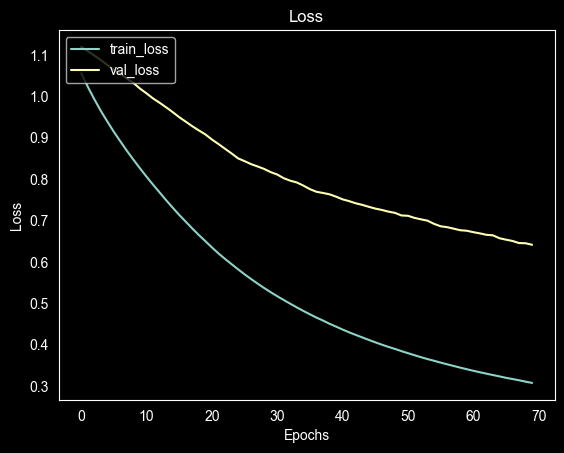

In [280]:
plt.figure()
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend(loc='upper left')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

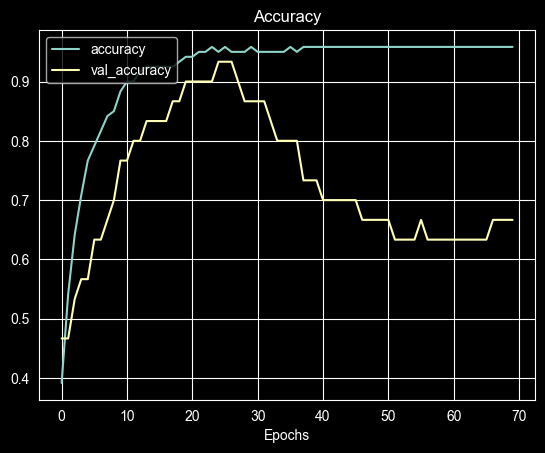

In [281]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.legend(loc='upper left')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.show()